## Beat the Market: An Effective Intraday Momentum Strategy for the S&P500 ETF (SPY)

This adapted implementation studies the strategy presented in the paper "Beat the Market: An Effective Intraday Momentum Strategy for the S&P500 ETF (SPY)" published by ConcretumGroup founder, **Carlo Zarattini**.

Co-authored by **Mohamed Gabriel**.

For detailed explanations, please refer to the full blog post.

You can reach the authors of this code by email at [info@concretumgroup.com](mailto:info@concretumgroup.com).

More information can be found at [www.concretumgroup.com](http://www.concretumgroup.com).






# 0. Needed Functions & Libraries

In [1]:
import requests
import time
import pandas as pd
from   datetime import datetime
import numpy as np
import pytz
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from   matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from IPython.display import display
from getpass import getpass
import os

c:\Users\prais\anaconda3\envs\ml-st\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
# Define the API key and base URLfrom getpass import getpass
API_KEY = getpass("Enter your API key: ")
BASE_URL = 'https://api.polygon.io'

# Define the rate limit enforcement based on the API tier
ENFORCE_RATE_LIMIT = True

def fetch_polygon_data(ticker, start_date, end_date, period, enforce_rate_limit=ENFORCE_RATE_LIMIT):
    """Fetch stock data from Polygon.io based on the given period (minute or day).
       enforce_rate_limit: Set to True to enforce rate limits (suitable for free tiers), False for paid tiers with minimal or no rate limits.
    """
    multiplier = '1'
    timespan = period
    limit = '50000'  # Maximum entries per request
    eastern = pytz.timezone('America/New_York')  # Eastern Time Zone

    url = f'{BASE_URL}/v2/aggs/ticker/{ticker}/range/{multiplier}/{timespan}/{start_date}/{end_date}?adjusted=false&sort=asc&limit={limit}&apiKey={API_KEY}'

    data_list = []
    request_count = 0
    first_request_time = None

    while True:
        if enforce_rate_limit and request_count == 5:
            elapsed_time = time.time() - first_request_time
            if elapsed_time < 60:
                wait_time = 60 - elapsed_time
                print(f"API rate limit reached. Waiting {wait_time:.2f} seconds before next request.")
                time.sleep(wait_time)
            request_count = 0
            first_request_time = time.time()  # Reset the timer after the wait

        if first_request_time is None and enforce_rate_limit:
            first_request_time = time.time()

        response = requests.get(url, timeout=30)
        if response.status_code == 429:
            print('Rate limited; retrying the same page in 65 seconds.')
            time.sleep(65)
            continue
        if not response.ok:
            # Avoid printing the request URL, which contains the API key.
            raise RuntimeError(f'Data request failed: HTTP {response.status_code}')

        data = response.json()
        request_count += 1

        results_count = len(data.get('results', []))
        print(f"Fetched {results_count} entries from API.")

        if 'results' in data:
            for entry in data['results']:
                utc_time = datetime.fromtimestamp(entry['t'] / 1000, pytz.utc)
                eastern_time = utc_time.astimezone(eastern)

                data_entry = {
                    'volume': entry['v'],
                    'open': entry['o'],
                    'high': entry['h'],
                    'low': entry['l'],
                    'close': entry['c'],
                    'caldt': eastern_time.replace(tzinfo=None)
                }

                if period == 'minute':
                    if eastern_time.time() >= datetime.strptime('09:30', '%H:%M').time() and eastern_time.time() <= datetime.strptime('15:59', '%H:%M').time():
                        data_list.append(data_entry)
                else:
                    data_list.append(data_entry)

        if 'next_url' in data and data['next_url']:
            url = data['next_url'] + '&apiKey=' + API_KEY
        else:
            break

    df = pd.DataFrame(data_list)
    print("Data fetching complete.")
    return df


def fetch_polygon_dividends(ticker):
    """ Fetches dividend data from Polygon.io for a specified stock ticker. """
    url = f'{BASE_URL}/v3/reference/dividends?ticker={ticker}&limit=1000&apiKey={API_KEY}'

    dividends_list = []
    while True:
        response = requests.get(url, timeout=30)
        if response.status_code == 429:
            print('Rate limited; retrying the same dividend page in 65 seconds.')
            time.sleep(65)
            continue
        if not response.ok:
            raise RuntimeError(f'Dividend request failed: HTTP {response.status_code}')
        data = response.json()
        if 'results' in data:
            for entry in data['results']:
                dividends_list.append({
                    'caldt': datetime.strptime(entry['ex_dividend_date'], '%Y-%m-%d'),
                    'dividend': entry['cash_amount']
                })

        if 'next_url' in data and data['next_url']:
            url = data['next_url'] + '&apiKey=' + API_KEY
        else:
            break

    return pd.DataFrame(dividends_list)



# 1. Download Data

In [7]:
ticker      = 'SPY'
from_date   = '2024-11-01'
until_date  = '2026-09-30'

spy_intra_data = fetch_polygon_data(ticker, from_date, until_date, 'minute')
spy_daily_data = fetch_polygon_data(ticker, from_date, until_date, 'day')
dividends      = fetch_polygon_dividends(ticker)


Fetched 50000 entries from API.
Fetched 50000 entries from API.
Fetched 50000 entries from API.
Fetched 50000 entries from API.
Fetched 50000 entries from API.
API rate limit reached. Waiting 43.61 seconds before next request.
Fetched 50000 entries from API.
Fetched 50000 entries from API.
Fetched 50000 entries from API.
Fetched 12255 entries from API.
Data fetching complete.
Fetched 478 entries from API.
Data fetching complete.


# 2. Add Key Variables

In [8]:
# Identified early-close sessions: retain data but do not trade.
short_session_days = {
    pd.Timestamp(d).date() for d in [
        '2024-11-29', '2024-12-24', '2025-07-03',
        '2025-11-28', '2025-12-24'
    ]
}

df = spy_intra_data.copy()
df['caldt'] = pd.to_datetime(df['caldt'])
assert not df['caldt'].duplicated().any(), 'Duplicate minute timestamps.'
df = df.set_index('caldt').sort_index()
df['day'] = df.index.date
assert df[['open', 'high', 'low', 'close', 'volume']].notna().all().all()
assert (df[['open', 'high', 'low', 'close']] > 0).all().all()
assert (df['volume'] >= 0).all()
assert (df['low'] <= df[['open', 'close']].min(axis=1)).all()
assert (df['high'] >= df[['open', 'close']].max(axis=1)).all()

daily_prices = spy_daily_data.copy()
daily_prices['day'] = pd.to_datetime(daily_prices['caldt']).dt.date
daily_prices = daily_prices.set_index('day').sort_index()
assert daily_prices.index.is_unique, 'Duplicate daily dates.'
assert daily_prices['close'].notna().all()
assert (daily_prices['close'] > 0).all()
all_days = sorted(df['day'].unique())
assert set(all_days).issubset(daily_prices.index), 'Daily prices are incomplete.'
assert all_days[0] == pd.Timestamp(from_date).date()
assert all_days[-1] == pd.Timestamp(until_date).date()

dividend_data = dividends.copy()
assert {'caldt', 'dividend'}.issubset(dividend_data.columns)
dividend_data['day'] = pd.to_datetime(dividend_data['caldt']).dt.date
dividend_by_day = dividend_data.groupby('day')['dividend'].sum()
df['dividend'] = df['day'].map(dividend_by_day).fillna(0.0)

bars_per_day = df.groupby('day').size()
unexpected = bars_per_day[(bars_per_day != 390)
                          & ~bars_per_day.index.isin(short_session_days)]
assert unexpected.empty, f'Unexpected short sessions: {unexpected.to_dict()}'
print('Rows:', len(df), '| Days:', len(all_days))
print('Coverage:', df.index.min(), 'to', df.index.max())
print('Short-session counts:')
print(bars_per_day[bars_per_day != 390])

# Absolute percentage move from that day's first opening price.
df['day_open'] = df.groupby('day')['open'].transform('first')
df['move_open'] = (df['close'] / df['day_open'] - 1).abs()

# Historical mean at the same clock time, excluding today's value.
df['time_of_day'] = df.index.time
df['sigma_open'] = df.groupby('time_of_day')['move_open'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=14).mean()
)

# Minute-bar approximation to cumulative daily VWAP; resets each morning.
hlc = (df['high'] + df['low'] + df['close']) / 3
weighted_price = df['volume'] * hlc
weighted_sum = weighted_price.groupby(df['day']).cumsum()
volume_sum = df.groupby('day')['volume'].cumsum()
df['vwap'] = weighted_sum / volume_sum.replace(0, np.nan)

# Previous daily close and dividend-adjusted boundary anchors.
daily_prices['prev_close'] = daily_prices['close'].shift(1)
df['prev_close_adjusted'] = (
    df['day'].map(daily_prices['prev_close']) - df['dividend']
)
upper_anchor = df[['day_open', 'prev_close_adjusted']].max(axis=1, skipna=False)
lower_anchor = df[['day_open', 'prev_close_adjusted']].min(axis=1, skipna=False)
df['UB'] = upper_anchor * (1 + df['sigma_open'])
df['LB'] = lower_anchor * (1 - df['sigma_open'])

# Daily sample volatility: previous 14 returns, never today's return.
daily_prices['ret'] = daily_prices['close'].pct_change(fill_method=None)
daily_prices['spy_dvol'] = (
    daily_prices['ret'].shift(1).rolling(14, min_periods=14).std(ddof=1)
)
df['spy_dvol'] = df['day'].map(daily_prices['spy_dvol'])
df['min_from_open'] = df.index.hour * 60 + df.index.minute - 570 + 1
display(df[['close', 'sigma_open', 'vwap', 'UB', 'LB']].dropna().head())


Rows: 185525 | Days: 478
Coverage: 2024-11-01 09:30:00 to 2026-09-30 15:59:00
Short-session counts:
day
2024-11-29    211
2024-12-24    211
2025-07-03    211
2025-11-28    211
2025-12-24    211
dtype: int64


,close,sigma_open,vwap,UB,LB
caldt,,,,,
2024-11-21 09:30:00,592.760,0.000473,592.976667,593.680643,590.220729
2024-11-21 09:31:00,593.410,0.000655,593.042497,593.788384,590.113514
2024-11-21 09:32:00,592.682,0.000601,593.028456,593.756491,590.145251
2024-11-21 09:33:00,592.530,0.000613,592.931820,593.763774,590.138003
2024-11-21 09:34:00,591.650,0.000894,592.753514,593.930590,589.972003


# 3. Backtest

In [9]:
# Constants and settings
AUM_0 = 100000.0
commission = 0.0035
min_comm_per_order = 0.35
slippage_per_share = 0.001
band_mult = 1
trade_freq = 30
target_vol = 0.02
max_leverage = 4
split_date = pd.Timestamp('2026-01-01')

# Check the prepared intraday data.
assert isinstance(df.index, pd.DatetimeIndex), "Restore the timestamp index."
assert df.index.is_unique, "Duplicate intraday timestamps found."

df = df.sort_index()
daily_groups = df.groupby('day')
all_days = sorted(daily_groups.groups)

# Previously identified early-close dates: no trading on these days.
short_session_days = {
    pd.Timestamp(date).date()
    for date in [
        '2024-11-29', '2024-12-24', '2025-07-03',
        '2025-11-28', '2025-12-24'
    ]
}

df_daily = daily_prices.copy()

# Initialize account and diagnostic results.
strat = pd.DataFrame(index=all_days)
strat.index.name = 'day'
strat['ret'] = 0.0
strat['AUM'] = AUM_0
strat['ret_spy'] = df_daily['ret'].reindex(all_days)
strat['shares'] = 0
strat['leverage'] = 0.0
strat['transaction_units'] = 0
strat['gross_pnl'] = 0.0
strat['costs'] = 0.0
strat['status'] = 'warmup'

# Simulate one trading day at a time.
for d in range(1, len(all_days)):
    current_day = all_days[d]
    prev_day = all_days[d - 1]
    day_data = daily_groups.get_group(current_day)

    previous_aum = strat.loc[prev_day, 'AUM']

    # Every skipped day carries forward capital.
    strat.loc[current_day, 'AUM'] = previous_aum

    if previous_aum <= 0:
        raise RuntimeError(f"Account capital exhausted before {current_day}.")

    spx_vol = df_daily.loc[current_day, 'spy_dvol']
    previous_close = df_daily.loc[current_day, 'prev_close']

    indicators_ready = (
        day_data[['sigma_open', 'vwap']].notna().all().all()
        and pd.notna(previous_close)
        and pd.notna(spx_vol)
        and spx_vol > 0
    )
    if not indicators_ready:
        continue

    if current_day in short_session_days:
        strat.loc[current_day, 'status'] = 'early_close'
        continue

    # Require a complete regular session for this simplified baseline.
    if (
        len(day_data) != 390
        or day_data.index[0].strftime('%H:%M') != '09:30'
        or day_data.index[-1].strftime('%H:%M') != '15:59'
    ):
        raise ValueError(f"Unexpected session coverage on {current_day}.")

    open_price = day_data['open'].iloc[0]
    close_prices = day_data['close']
    vwap = day_data['vwap']
    sigma_open = day_data['sigma_open']

    # Dividend-adjusted noise boundaries.
    prev_close_adjusted = previous_close - day_data['dividend'].iloc[0]
    UB = max(open_price, prev_close_adjusted) * (1 + band_mult * sigma_open)
    LB = min(open_price, prev_close_adjusted) * (1 - band_mult * sigma_open)

    signals = pd.Series(0.0, index=day_data.index)
    signals.loc[(close_prices > UB) & (close_prices > vwap)] = 1.0
    signals.loc[(close_prices < LB) & (close_prices < vwap)] = -1.0

    # Paper's volatility-based exposure, capped at 4x.
    leverage = min(target_vol / spx_vol, max_leverage)
    shares = math.floor(previous_aum * leverage / open_price)

    # Bar labels are start times: 09:59 finishes at 10:00.
    minutes_from_open = (
        day_data.index.hour * 60
        + day_data.index.minute
        - (9 * 60 + 30)
        + 1
    )
    decision_time = minutes_from_open % trade_freq == 0

    target_position = signals.where(decision_time)
    target_position.iloc[-1] = 0.0  # Liquidate at session end.

    # Hold between decisions; earn only subsequent price changes.
    exposure = (
        target_position.ffill().shift(1).fillna(0.0).to_numpy()
    )

    # Include entry, reversals, and final liquidation.
    transaction_units = int(
        np.abs(np.diff(np.r_[0.0, exposure, 0.0])).sum()
    )

    change_1m = close_prices.diff().fillna(0.0).to_numpy()
    gross_pnl = float(np.sum(exposure * change_1m) * shares)

    if shares > 0:
        commission_paid = transaction_units * max(
            min_comm_per_order, commission * shares
        )
        slippage_paid = transaction_units * shares * slippage_per_share
    else:
        commission_paid = 0.0
        slippage_paid = 0.0

    costs = commission_paid + slippage_paid
    net_pnl = gross_pnl - costs

    strat.loc[current_day, 'AUM'] = previous_aum + net_pnl
    strat.loc[current_day, 'ret'] = net_pnl / previous_aum
    strat.loc[current_day, 'shares'] = shares
    strat.loc[current_day, 'leverage'] = leverage
    strat.loc[current_day, 'transaction_units'] = transaction_units
    strat.loc[current_day, 'gross_pnl'] = gross_pnl
    strat.loc[current_day, 'costs'] = costs
    strat.loc[current_day, 'status'] = 'evaluated'

print(strat.tail())
print(strat['status'].value_counts())
print("Total modeled costs:", strat['costs'].sum())
expected_aum = AUM_0 * (1 + strat['ret']).cumprod()
assert np.allclose(strat['AUM'], expected_aum)
assert np.allclose(strat['AUM'].diff().iloc[1:],
                   (strat['gross_pnl'] - strat['costs']).iloc[1:])
skipped = strat['status'].isin(['warmup', 'early_close'])
assert (strat.loc[skipped, ['ret', 'costs', 'transaction_units']] == 0).all().all()
assert strat['leverage'].between(0, max_leverage).all()
assert np.isfinite(strat[['AUM', 'ret', 'gross_pnl', 'costs']].to_numpy()).all()
evaluation = strat.loc[strat['status'] != 'warmup'].copy()
evaluation.index = pd.to_datetime(evaluation.index)
train = evaluation.loc[evaluation.index < split_date]
test = evaluation.loc[evaluation.index >= split_date]
assert not train.empty and not test.empty
assert train.index.intersection(test.index).empty
print('Accounting and split checks passed.')


                 ret         AUM   ret_spy  shares  leverage  \
day                                                            
2026-09-24  0.000000  95975.7111 -0.000821     327  2.604739   
2026-09-25 -0.006250  95375.8521  0.005435     351  2.818453   
2026-09-28 -0.016509  93801.2721 -0.007441     345  2.779634   
2026-09-29 -0.003689  93455.2185 -0.001842     333  2.728517   
2026-09-30 -0.002078  93261.0054 -0.002054     337  2.765851   

            transaction_units  gross_pnl  costs     status  
day                                                         
2026-09-24                  0     0.0000  0.000  evaluated  
2026-09-25                  4  -593.5410  6.318  evaluated  
2026-09-28                  2 -1571.4750  3.105  evaluated  
2026-09-29                  2  -343.0566  2.997  evaluated  
2026-09-30                  4  -188.1471  6.066  evaluated  
status
evaluated      458
warmup          15
early_close      5
Name: count, dtype: int64
Total modeled costs: 1584.054
Acco

# 4. Study Results

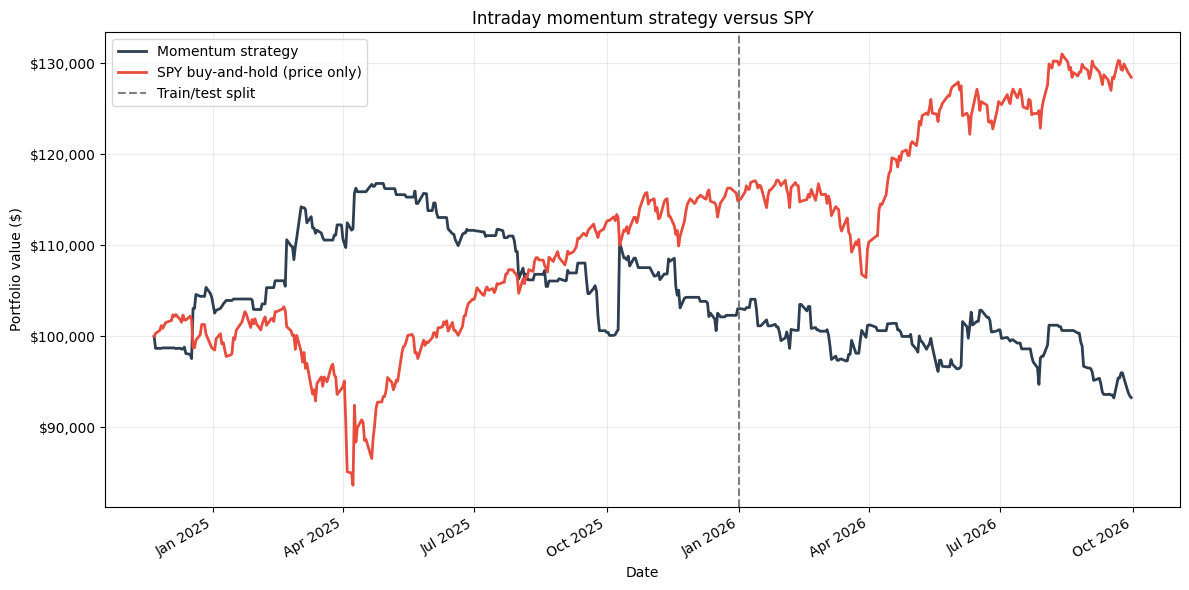

,Total return,Annualized return,Annualized volatility,Sharpe ratio
Train — Strategy,3.03%,2.77%,15.97%,0.25
Train — SPY price return,14.87%,13.49%,18.95%,0.76
Test — Strategy,-9.48%,-12.57%,13.67%,-0.91
Test — SPY price return,11.84%,16.27%,13.19%,1.21


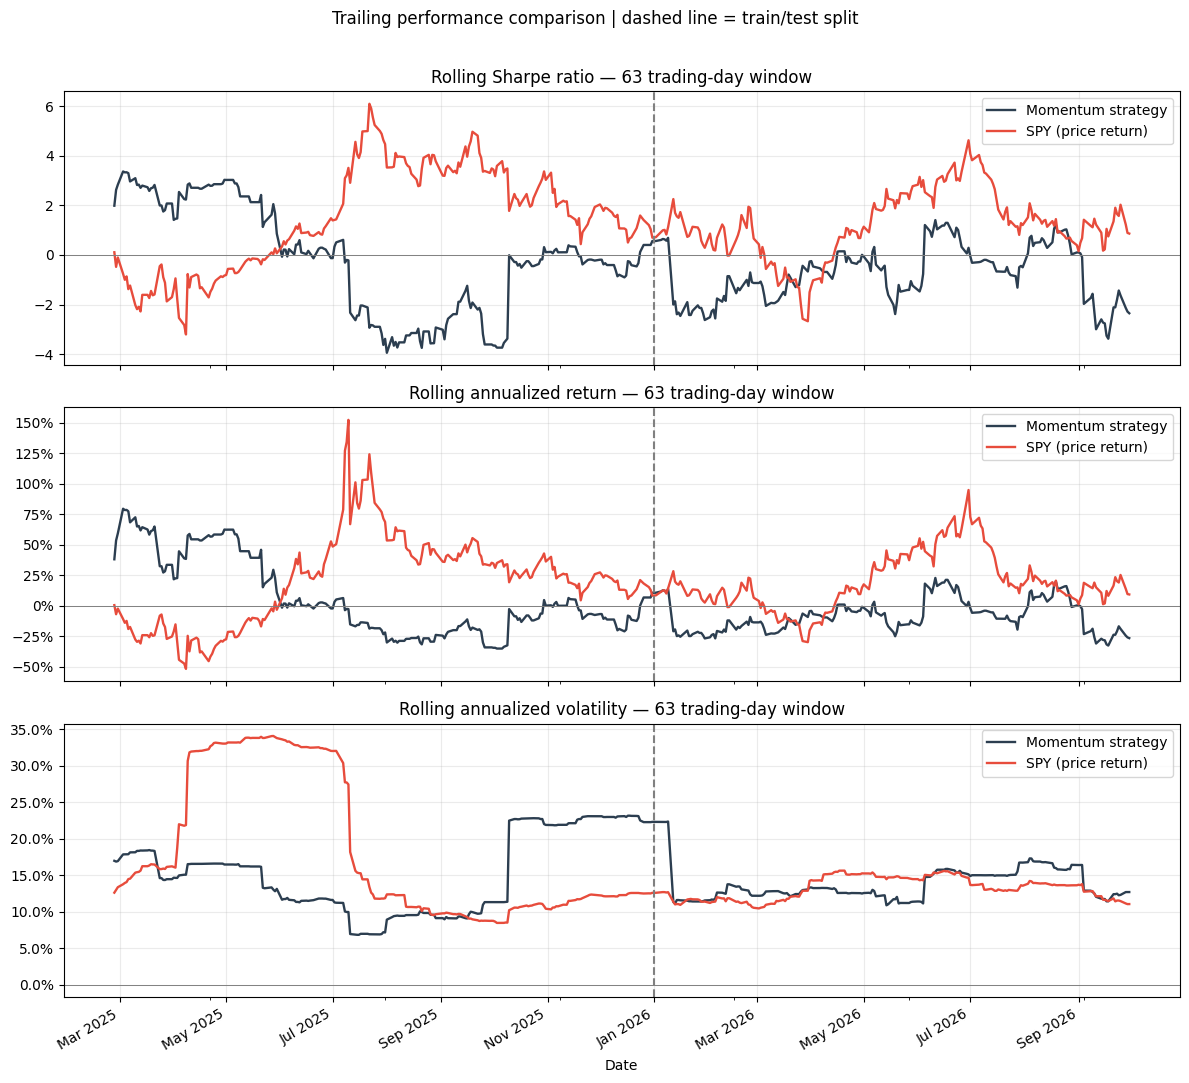

In [10]:
rolling_window = 63

equity = pd.DataFrame({
    'Momentum strategy': AUM_0 * (1 + evaluation['ret']).cumprod(),
    'SPY buy-and-hold (price only)': AUM_0 * (1 + evaluation['ret_spy']).cumprod()
})
start = pd.DataFrame(AUM_0, index=[equity.index[0] - pd.Timedelta(days=1)],
                     columns=equity.columns)
equity = pd.concat([start, equity])

fig, ax = plt.subplots(figsize=(12, 6))
equity.plot(ax=ax, color=['#2C3E50', '#E74C3C'], linewidth=2)
ax.axvline(split_date, color='gray', linestyle='--', label='Train/test split')
ax.set_title('Intraday momentum strategy versus SPY')
ax.set_ylabel('Portfolio value ($)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

def performance_metrics(returns):
    returns = returns.astype(float)

    if returns.empty or returns.isna().any():
        raise ValueError("Returns must be nonempty and contain no missing values.")
    if (returns <= -1).any():
        raise ValueError("A return of -100% or below invalidates this calculation.")

    growth = (1 + returns).prod()
    daily_vol = returns.std(ddof=1)

    return {
        'Total return': growth - 1,
        'Annualized return': growth ** (252 / len(returns)) - 1,
        'Annualized volatility': daily_vol * np.sqrt(252),
        'Sharpe ratio': (
            returns.mean() / daily_vol * np.sqrt(252)
            if daily_vol > 0 else np.nan
        )
    }


metrics = pd.DataFrame({
    'Train — Strategy': performance_metrics(train['ret']),
    'Train — SPY price return': performance_metrics(train['ret_spy']),
    'Test — Strategy': performance_metrics(test['ret']),
    'Test — SPY price return': performance_metrics(test['ret_spy'])
}).T

formatted_metrics = metrics.copy().astype(object)
for column in ['Total return', 'Annualized return', 'Annualized volatility']:
    formatted_metrics[column] = metrics[column].map(lambda x: f'{x:.2%}')
formatted_metrics['Sharpe ratio'] = metrics['Sharpe ratio'].map(lambda x: f'{x:.2f}')
display(formatted_metrics)

# Trailing metrics are descriptive: each point uses the previous 63 daily returns
# including that date. They are not signals and do not alter the backtest.
returns = evaluation[['ret', 'ret_spy']].rename(columns={
    'ret': 'Momentum strategy', 'ret_spy': 'SPY (price return)'
})
window = returns.rolling(rolling_window, min_periods=rolling_window)
mean = window.mean()
std = window.std(ddof=1)
rolling_sharpe = mean.div(std.replace(0, np.nan)) * np.sqrt(252)
rolling_return = (1 + returns).rolling(
    rolling_window, min_periods=rolling_window
).apply(np.prod, raw=True) ** (252 / rolling_window) - 1
rolling_vol = std * np.sqrt(252)

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
panels = [
    ('Rolling Sharpe ratio', rolling_sharpe),
    ('Rolling annualized return', rolling_return),
    ('Rolling annualized volatility', rolling_vol)
]
for ax, (title, series) in zip(axes, panels):
    series.plot(ax=ax, color=['#2C3E50', '#E74C3C'], linewidth=1.7)
    ax.axvline(split_date, color='gray', linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.set_title(f'{title} — {rolling_window} trading-day window')
    ax.grid(alpha=0.25)
    ax.set_xlabel('')
    if title != 'Rolling Sharpe ratio':
        ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.suptitle('Trailing performance comparison | dashed line = train/test split')
fig.autofmt_xdate()
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


# 5. Original Variation

,Total return,Annualized return,Annualized volatility,Sharpe ratio
Train — Baseline,3.03%,2.77%,15.97%,0.25
Train — Variation,5.78%,5.27%,15.44%,0.41
Train — SPY (price return),14.87%,13.49%,18.95%,0.76
Test — Baseline,-9.48%,-12.57%,13.67%,-0.91
Test — Variation,-6.24%,-8.32%,13.01%,-0.60
Test — SPY (price return),11.84%,16.27%,13.19%,1.21


Blocked entry attempts: 363
Baseline transaction units: 836
Variation transaction units: 624
Baseline costs: 1584.054
Variation costs: 1219.797


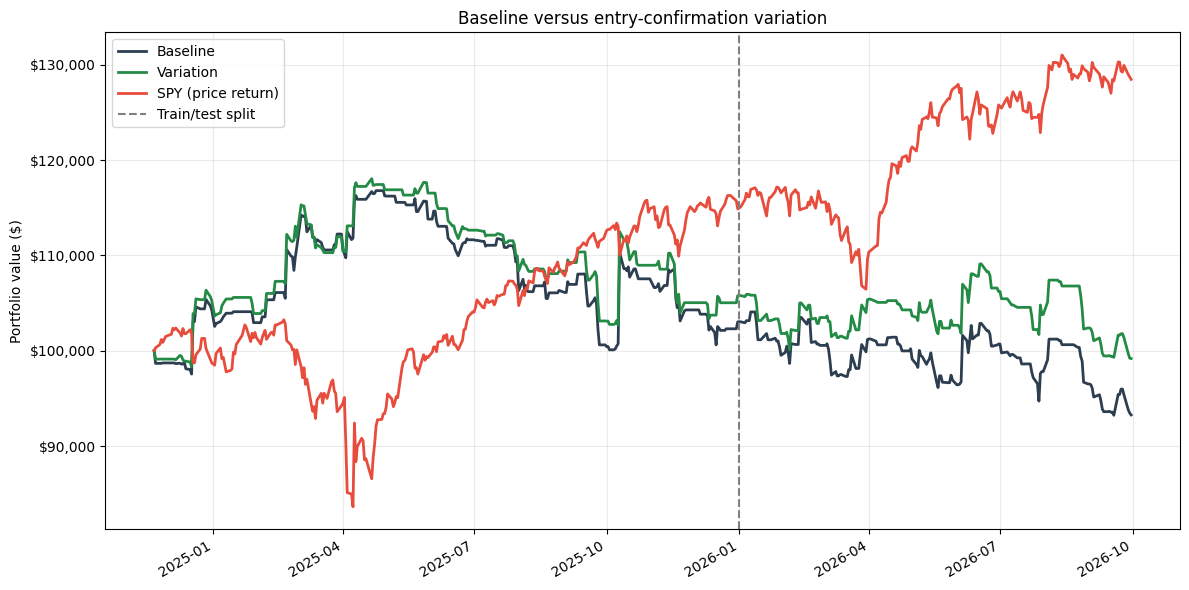

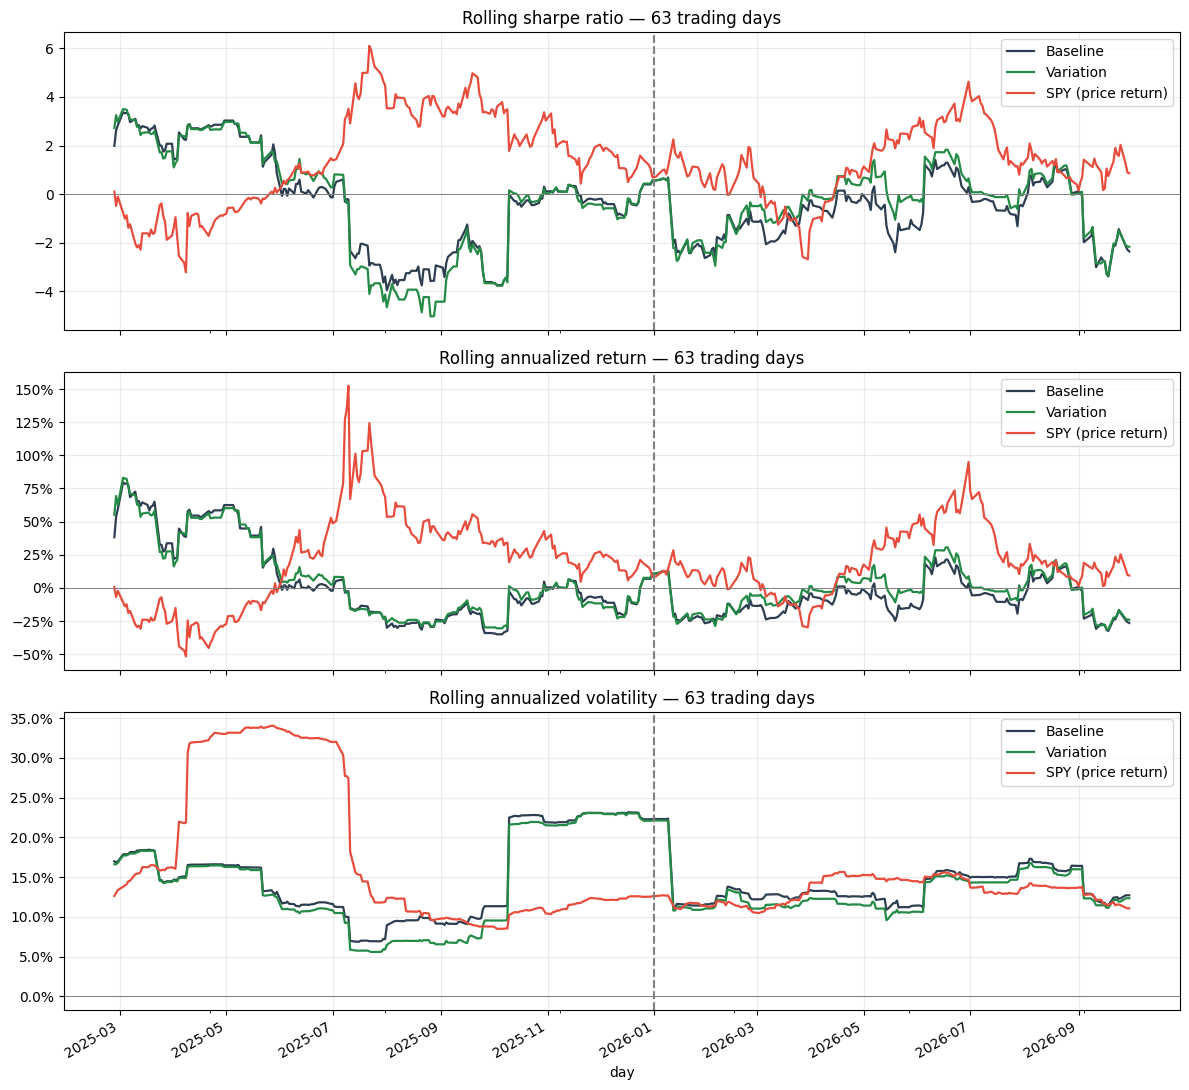

In [11]:
# 5. Original Variation: Stronger 30-Minute Move Confirmation
#
# New entries require a stronger signed 30-minute return than the
# previous available returns (maximum lookback: three intervals).
# The first decision of each day uses the baseline entry rule.
# Existing positions retain the baseline band/VWAP exit conditions.

confirmation_lookback = 3

# Preserve the baseline results.
baseline = strat.copy()

variation = pd.DataFrame(index=baseline.index)
variation.index.name = 'day'
variation['AUM'] = AUM_0
variation['ret'] = 0.0
variation['ret_spy'] = baseline['ret_spy']
variation['gross_pnl'] = 0.0
variation['costs'] = 0.0
variation['shares'] = 0
variation['leverage'] = 0.0
variation['transaction_units'] = 0
variation['blocked_entries'] = 0

# Use identical data-availability and early-close eligibility.
variation['status'] = baseline['status']

days = list(variation.index)
groups = df.groupby('day')

for d in range(1, len(days)):
    current_day = days[d]
    previous_day = days[d - 1]
    previous_aum = variation.loc[previous_day, 'AUM']

    variation.loc[current_day, 'AUM'] = previous_aum

    if previous_aum <= 0:
        raise RuntimeError(f"Capital exhausted before {current_day}.")

    if variation.loc[current_day, 'status'] != 'evaluated':
        continue

    day_data = groups.get_group(current_day)
    close_prices = day_data['close']
    open_price = day_data['open'].iloc[0]
    sigma = day_data['sigma_open']
    vwap = day_data['vwap']

    previous_close = df_daily.loc[current_day, 'prev_close']
    adjusted_close = previous_close - day_data['dividend'].iloc[0]

    upper = max(open_price, adjusted_close) * (1 + band_mult * sigma)
    lower = min(open_price, adjusted_close) * (1 - band_mult * sigma)

    # Unchanged baseline directional conditions.
    candidate = pd.Series(0.0, index=day_data.index)
    candidate.loc[
        (close_prices > upper) & (close_prices > vwap)
    ] = 1.0
    candidate.loc[
        (close_prices < lower) & (close_prices < vwap)
    ] = -1.0

    minutes_from_open = (
        day_data.index.hour * 60
        + day_data.index.minute
        - 570
        + 1
    )
    decision_mask = minutes_from_open % trade_freq == 0
    decision_prices = close_prices.loc[decision_mask]

    # Completed interval returns:
    # first decision close / today's open - 1;
    # thereafter current decision close / previous decision close - 1.
    interval_returns = decision_prices.pct_change(fill_method=None)
    interval_returns.iloc[0] = decision_prices.iloc[0] / open_price - 1

    # Exclude the current interval from its comparison history.
    past_returns = interval_returns.shift(1)
    previous_max = past_returns.rolling(
        confirmation_lookback, min_periods=1
    ).max()
    previous_min = past_returns.rolling(
        confirmation_lookback, min_periods=1
    ).min()

    allow_long = (
        (interval_returns > 0)
        & (interval_returns > previous_max)
    )
    allow_short = (
        (interval_returns < 0)
        & (interval_returns < previous_min)
    )

    # Your chosen exception: no extra filter at the first decision.
    allow_long.iloc[0] = True
    allow_short.iloc[0] = True

    # Track position explicitly so this filter affects ENTRY only.
    target = pd.Series(np.nan, index=day_data.index)
    position = 0.0
    blocked = 0

    for timestamp in decision_prices.index:
        desired = candidate.loc[timestamp]

        if timestamp == day_data.index[-1]:
            position = 0.0  # Final liquidation; never open at the close.

        elif desired != position:
            # The old position no longer satisfies its baseline holding rule.
            position = 0.0

            # Any new position, including a reversal, requires confirmation.
            if desired == 1.0:
                if allow_long.loc[timestamp]:
                    position = 1.0
                else:
                    blocked += 1

            elif desired == -1.0:
                if allow_short.loc[timestamp]:
                    position = -1.0
                else:
                    blocked += 1

        # If desired == position, keep the existing position.
        # A failed entry filter alone never closes an existing position.
        target.loc[timestamp] = position

    target.iloc[-1] = 0.0
    exposure = target.ffill().shift(1).fillna(0.0).to_numpy()

    # Same volatility-sizing rule, using this portfolio's own capital.
    daily_vol = df_daily.loc[current_day, 'spy_dvol']
    leverage = min(target_vol / daily_vol, max_leverage)
    shares = math.floor(previous_aum * leverage / open_price)

    transaction_units = int(
        np.abs(np.diff(np.r_[0.0, exposure, 0.0])).sum()
    )

    price_changes = close_prices.diff().fillna(0.0).to_numpy()
    gross_pnl = float(np.sum(exposure * price_changes) * shares)

    if shares > 0:
        commission_paid = transaction_units * max(
            min_comm_per_order, commission * shares
        )
        slippage_paid = transaction_units * shares * slippage_per_share
    else:
        commission_paid = 0.0
        slippage_paid = 0.0

    costs = commission_paid + slippage_paid
    net_pnl = gross_pnl - costs

    variation.loc[current_day, 'AUM'] = previous_aum + net_pnl
    variation.loc[current_day, 'ret'] = net_pnl / previous_aum
    variation.loc[current_day, 'gross_pnl'] = gross_pnl
    variation.loc[current_day, 'costs'] = costs
    variation.loc[current_day, 'shares'] = shares
    variation.loc[current_day, 'leverage'] = leverage
    variation.loc[current_day, 'transaction_units'] = transaction_units
    variation.loc[current_day, 'blocked_entries'] = blocked


# Accounting verification.
assert np.allclose(
    variation['AUM'],
    AUM_0 * (1 + variation['ret']).cumprod()
)
assert np.allclose(
    variation['AUM'].diff().iloc[1:],
    (variation['gross_pnl'] - variation['costs']).iloc[1:]
)
skipped = variation['status'] != 'evaluated'
assert (
    variation.loc[skipped, ['ret', 'costs', 'transaction_units']] == 0
).all().all()
assert variation['leverage'].between(0, max_leverage).all()
assert np.isfinite(
    variation[['AUM', 'ret', 'gross_pnl', 'costs']].to_numpy()
).all()


# Compare on identical dates, excluding warmup.
baseline_eval = baseline.loc[baseline['status'] != 'warmup'].copy()
variation_eval = variation.loc[variation['status'] != 'warmup'].copy()

baseline_eval.index = pd.to_datetime(baseline_eval.index)
variation_eval.index = pd.to_datetime(variation_eval.index)
assert baseline_eval.index.equals(variation_eval.index)

comparison_returns = pd.DataFrame({
    'Baseline': baseline_eval['ret'],
    'Variation': variation_eval['ret'],
    'SPY (price return)': baseline_eval['ret_spy']
})

split_date = pd.Timestamp('2026-01-01')
comparison_rows = {}

for period, mask in [
    ('Train', comparison_returns.index < split_date),
    ('Test', comparison_returns.index >= split_date)
]:
    for name in comparison_returns.columns:
        comparison_rows[f'{period} — {name}'] = performance_metrics(
            comparison_returns.loc[mask, name]
        )

comparison_metrics = pd.DataFrame(comparison_rows).T
formatted = comparison_metrics.copy().astype(object)

for column in [
    'Total return', 'Annualized return', 'Annualized volatility'
]:
    formatted[column] = comparison_metrics[column].map(
        lambda value: f'{value:.2%}'
    )
formatted['Sharpe ratio'] = comparison_metrics['Sharpe ratio'].map(
    lambda value: f'{value:.2f}'
)

display(formatted)
print("Blocked entry attempts:", variation['blocked_entries'].sum())
print("Baseline transaction units:", baseline['transaction_units'].sum())
print("Variation transaction units:", variation['transaction_units'].sum())
print("Baseline costs:", baseline['costs'].sum())
print("Variation costs:", variation['costs'].sum())


# Equity comparison: same initial capital and evaluation dates.
equity_comparison = AUM_0 * (1 + comparison_returns).cumprod()
starting_point = pd.DataFrame(
    AUM_0,
    index=[equity_comparison.index[0] - pd.Timedelta(days=1)],
    columns=equity_comparison.columns
)
equity_comparison = pd.concat([starting_point, equity_comparison])

colors = ['#2C3E50', '#238B45', '#E74C3C']
fig, ax = plt.subplots(figsize=(12, 6))
equity_comparison.plot(ax=ax, color=colors, linewidth=2)
ax.axvline(split_date, color='gray', linestyle='--', label='Train/test split')
ax.set_title('Baseline versus entry-confirmation variation')
ax.set_ylabel('Portfolio value ($)')
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# Rolling metric line graphs, using the same 63-day display window.
rolling_window = 63
rolling = comparison_returns.rolling(
    rolling_window, min_periods=rolling_window
)
rolling_std = rolling.std(ddof=1)

rolling_sharpe = (
    rolling.mean() / rolling_std.replace(0, np.nan) * np.sqrt(252)
)
rolling_annual_return = (
    (1 + comparison_returns)
    .rolling(rolling_window, min_periods=rolling_window)
    .apply(np.prod, raw=True)
    ** (252 / rolling_window)
    - 1
)
rolling_annual_vol = rolling_std * np.sqrt(252)

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for ax, title, values in zip(
    axes,
    ['Sharpe ratio', 'Annualized return', 'Annualized volatility'],
    [rolling_sharpe, rolling_annual_return, rolling_annual_vol]
):
    values.plot(ax=ax, color=colors, linewidth=1.6)
    ax.axvline(split_date, color='gray', linestyle='--')
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.set_title(f'Rolling {title.lower()} — {rolling_window} trading days')
    ax.grid(alpha=0.25)

    if title != 'Sharpe ratio':
        ax.yaxis.set_major_formatter(PercentFormatter(1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()